# Task 1A: Exploratory Data Analysis
## Mental Health Smartphone Dataset

This notebook performs exploratory data analysis on the mood/smartphone dataset.
We examine dataset statistics, distributions, missing values, temporal patterns, and variable relationships.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 1. Data Loading and First Inspection

In [26]:
df = pd.read_csv("../data/dataset_mood_smartphone.csv", index_col=0)
df["time"] = pd.to_datetime(df["time"])

print(f"Shape: {df.shape}")
print(f"Number of records: {len(df):,}")
print(f"Number of patients: {df['id'].nunique()}")
print(f"Number of variables: {df['variable'].nunique()}")
print(f"Time range: {df['time'].min()} to {df['time'].max()}")
print()
df.head(10)

Shape: (376912, 4)
Number of records: 376,912
Number of patients: 27
Number of variables: 19
Time range: 2014-02-17 07:00:52.197000 to 2014-06-09 00:00:00



,id,time,variable,value
1,AS14.01,2014-02-26 13:00:00,mood,6.0
2,AS14.01,2014-02-26 15:00:00,mood,6.0
3,AS14.01,2014-02-26 18:00:00,mood,6.0
4,AS14.01,2014-02-26 21:00:00,mood,7.0
5,AS14.01,2014-02-27 09:00:00,mood,6.0
6,AS14.01,2014-02-27 12:00:00,mood,6.0
7,AS14.01,2014-02-27 15:00:00,mood,7.0
8,AS14.01,2014-03-21 09:00:00,mood,6.0
9,AS14.01,2014-03-21 11:00:00,mood,6.0
10,AS14.01,2014-03-21 15:00:00,mood,7.0


In [27]:
# Data types and info
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 376912 entries, 1 to 2784435
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   id        376912 non-null  object        
 1   time      376912 non-null  datetime64[ns]
 2   variable  376912 non-null  object        
 3   value     376710 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 14.4+ MB


In [28]:
# List all unique variables and patient IDs
print("Variables:")
print(sorted(df["variable"].unique()))
print(f"\nPatient IDs ({df['id'].nunique()}):")
print(sorted(df["id"].unique()))

Variables:
['activity', 'appCat.builtin', 'appCat.communication', 'appCat.entertainment', 'appCat.finance', 'appCat.game', 'appCat.office', 'appCat.other', 'appCat.social', 'appCat.travel', 'appCat.unknown', 'appCat.utilities', 'appCat.weather', 'call', 'circumplex.arousal', 'circumplex.valence', 'mood', 'screen', 'sms']

Patient IDs (27):
['AS14.01', 'AS14.02', 'AS14.03', 'AS14.05', 'AS14.06', 'AS14.07', 'AS14.08', 'AS14.09', 'AS14.12', 'AS14.13', 'AS14.14', 'AS14.15', 'AS14.16', 'AS14.17', 'AS14.19', 'AS14.20', 'AS14.23', 'AS14.24', 'AS14.25', 'AS14.26', 'AS14.27', 'AS14.28', 'AS14.29', 'AS14.30', 'AS14.31', 'AS14.32', 'AS14.33']


## 2. Dataset Statistics - Summary Table per Variable

For each variable we compute: count, missing values, data type, min, max, mean, median, and standard deviation.

In [29]:
# Summary statistics per variable
summary = df.groupby("variable")["value"].agg(
    count="count",
    missing=lambda x: x.isna().sum(),
    missing_pct=lambda x: round(100 * x.isna().mean(), 2),
    mean="mean",
    std="std",
    median="median",
    min="min",
    max="max",
).reset_index()

summary["type"] = summary["variable"].apply(
    lambda v: "ordinal (1-10)" if v == "mood"
    else "continuous (-2 to 2)" if "circumplex" in v
    else "binary" if v in ["call", "sms"]
    else "continuous (0-1)" if v == "activity"
    else "continuous (duration)" if v == "screen" or "appCat" in v
    else "unknown"
)

summary = summary[["variable", "type", "count", "missing", "missing_pct", "min", "max", "mean", "median", "std"]]
summary.round(3)

,variable,type,count,missing,missing_pct,min,max,mean,median,std
0,activity,continuous (0-1),22965,0,0.00,0.000,1.000,0.116,0.022,0.187
1,appCat.builtin,continuous (duration),91288,0,0.00,-82798.871,33960.246,18.538,4.038,415.989
2,appCat.communication,continuous (duration),74276,0,0.00,0.006,9830.777,43.344,16.226,128.913
3,appCat.entertainment,continuous (duration),27125,0,0.00,-0.011,32148.677,37.576,3.391,262.960
4,appCat.finance,continuous (duration),939,0,0.00,0.131,355.513,21.755,8.026,39.218
5,appCat.game,continuous (duration),813,0,0.00,1.003,5491.793,128.392,43.168,327.145
6,appCat.office,continuous (duration),5642,0,0.00,0.003,32708.818,22.579,3.106,449.601
7,appCat.other,continuous (duration),7650,0,0.00,0.014,3892.038,25.811,10.028,112.781
8,appCat.social,continuous (duration),19145,0,0.00,0.094,30000.906,72.402,28.466,261.552
9,appCat.travel,continuous (duration),2846,0,0.00,0.080,10452.615,45.731,18.144,246.109


**TODO: interpret these results.** Discuss which variables have the most records, what the value ranges tell us, and whether the attribute types make sense.

## 3. Records per Variable and per Patient

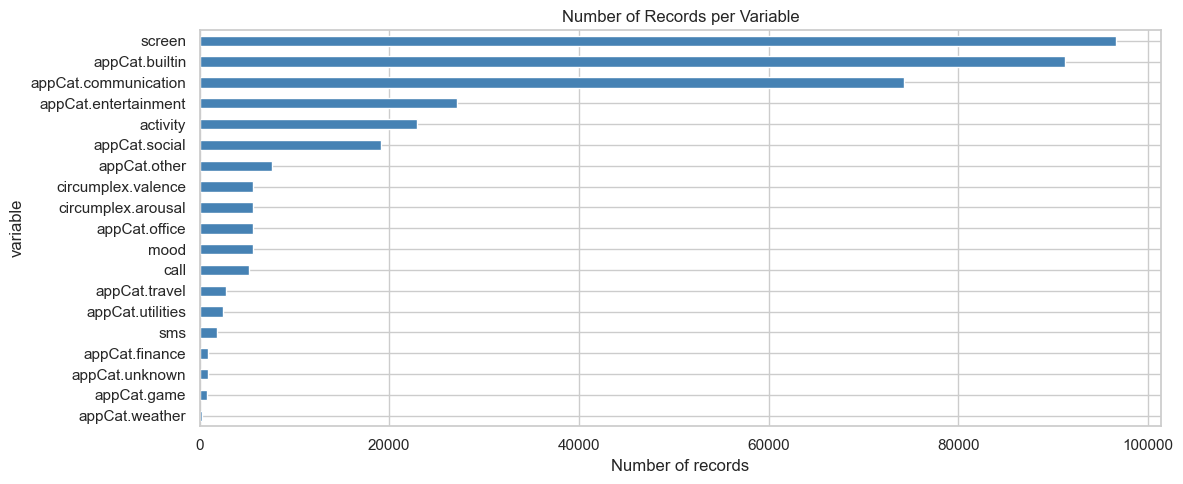

In [30]:
# Records per variable
fig, ax = plt.subplots(figsize=(12, 5))
counts = df.groupby("variable").size().sort_values(ascending=True)
counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Number of records")
ax.set_title("Number of Records per Variable")
plt.tight_layout()
plt.show()

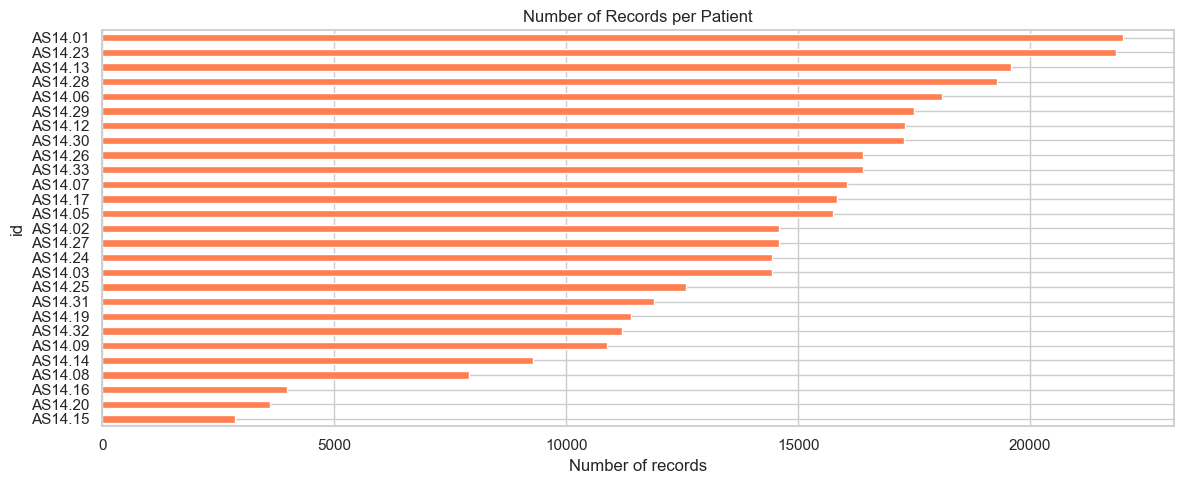

In [31]:
# Records per patient
fig, ax = plt.subplots(figsize=(12, 5))
patient_counts = df.groupby("id").size().sort_values(ascending=True)
patient_counts.plot(kind="barh", ax=ax, color="coral")
ax.set_xlabel("Number of records")
ax.set_title("Number of Records per Patient")
plt.tight_layout()
plt.show()

## 4. Missing Value Analysis

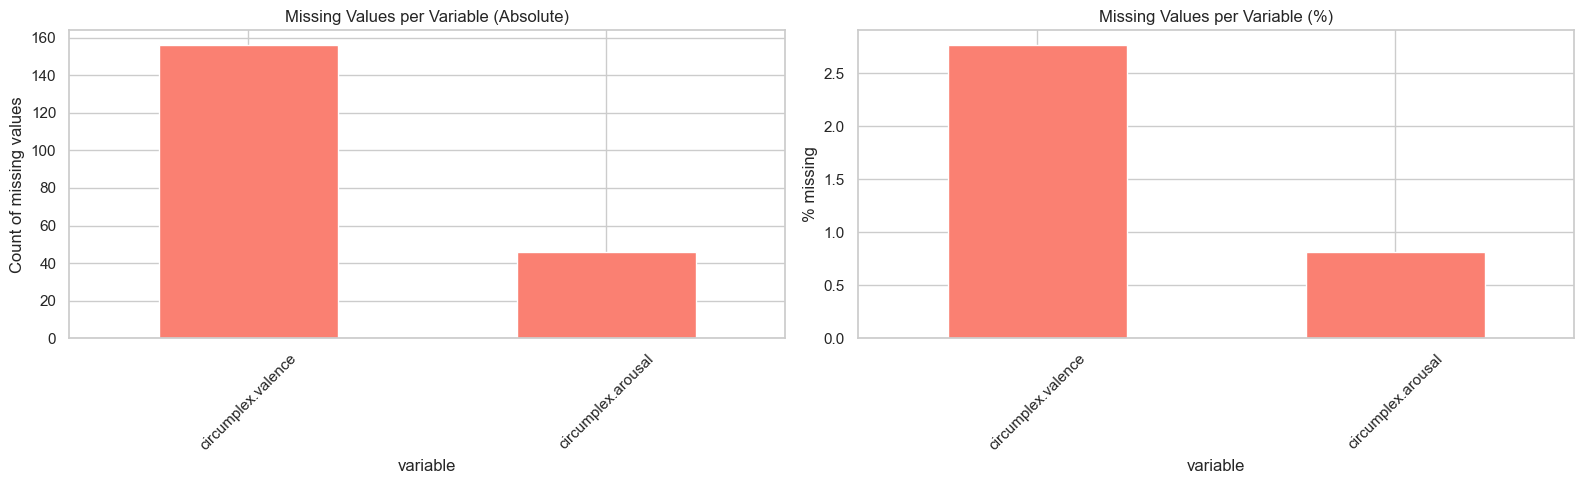

In [32]:
# Missing values per variable
missing_by_var = df[df["value"].isna()].groupby("variable").size().sort_values(ascending=False)
total_by_var = df.groupby("variable").size()
missing_pct_var = (missing_by_var / total_by_var * 100).dropna().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

missing_by_var.plot(kind="bar", ax=axes[0], color="salmon")
axes[0].set_title("Missing Values per Variable (Absolute)")
axes[0].set_ylabel("Count of missing values")
axes[0].tick_params(axis="x", rotation=45)

missing_pct_var.plot(kind="bar", ax=axes[1], color="salmon")
axes[1].set_title("Missing Values per Variable (%)")
axes[1].set_ylabel("% missing")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

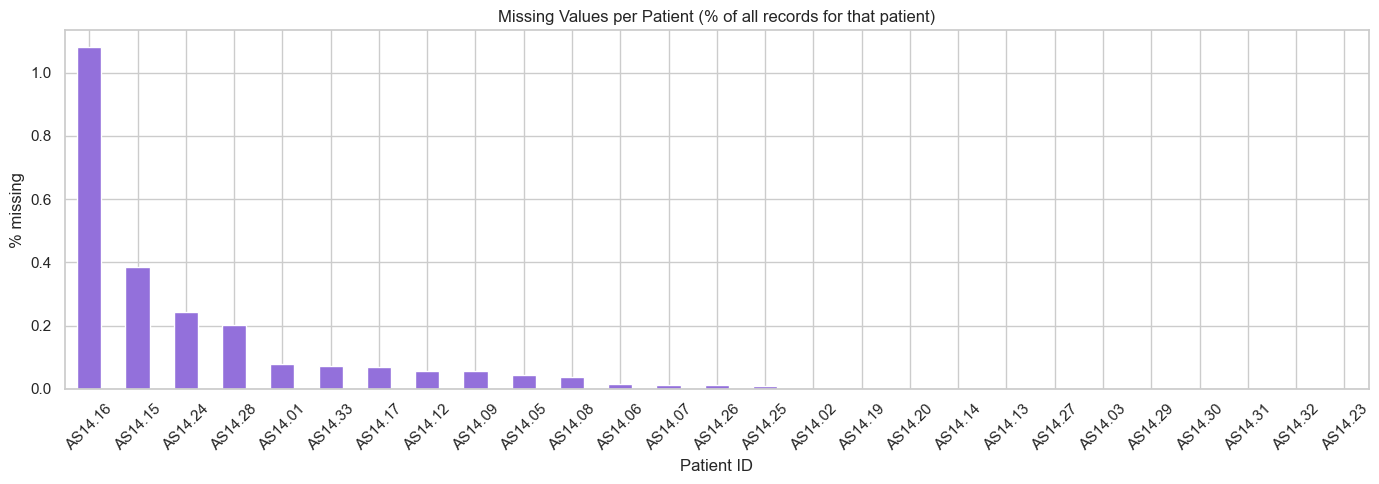

In [33]:
# Missing values per patient (across all variables)
missing_by_patient = df[df["value"].isna()].groupby("id").size().reindex(df["id"].unique(), fill_value=0)
total_by_patient = df.groupby("id").size()
missing_pct_patient = (missing_by_patient / total_by_patient * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
missing_pct_patient.plot(kind="bar", ax=ax, color="mediumpurple")
ax.set_title("Missing Values per Patient (% of all records for that patient)")
ax.set_ylabel("% missing")
ax.set_xlabel("Patient ID")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

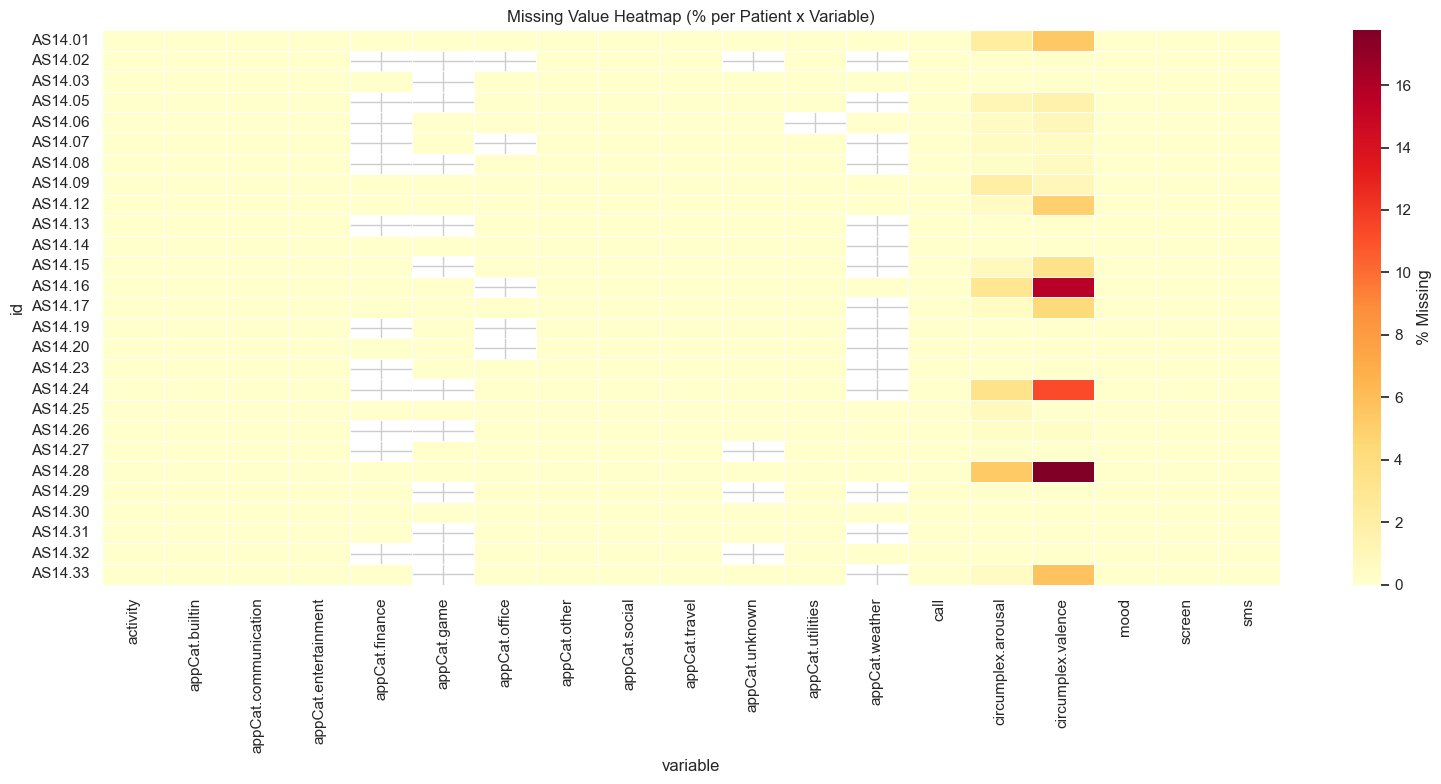

In [34]:
# Heatmap: missing value percentage per (patient, variable)
missing_pivot = df.pivot_table(
    index="id", columns="variable", values="value",
    aggfunc=lambda x: x.isna().mean() * 100
)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(missing_pivot, cmap="YlOrRd", annot=False, fmt=".0f",
            linewidths=0.5, ax=ax, cbar_kws={"label": "% Missing"})
ax.set_title("Missing Value Heatmap (% per Patient x Variable)")
plt.tight_layout()
plt.show()

**TODO: interpret these results.** Which variables have the most missing data? Are there patients with significantly more missing values? What could explain these patterns?

## 5. Distribution Analysis

### 5.1 Mood Distribution

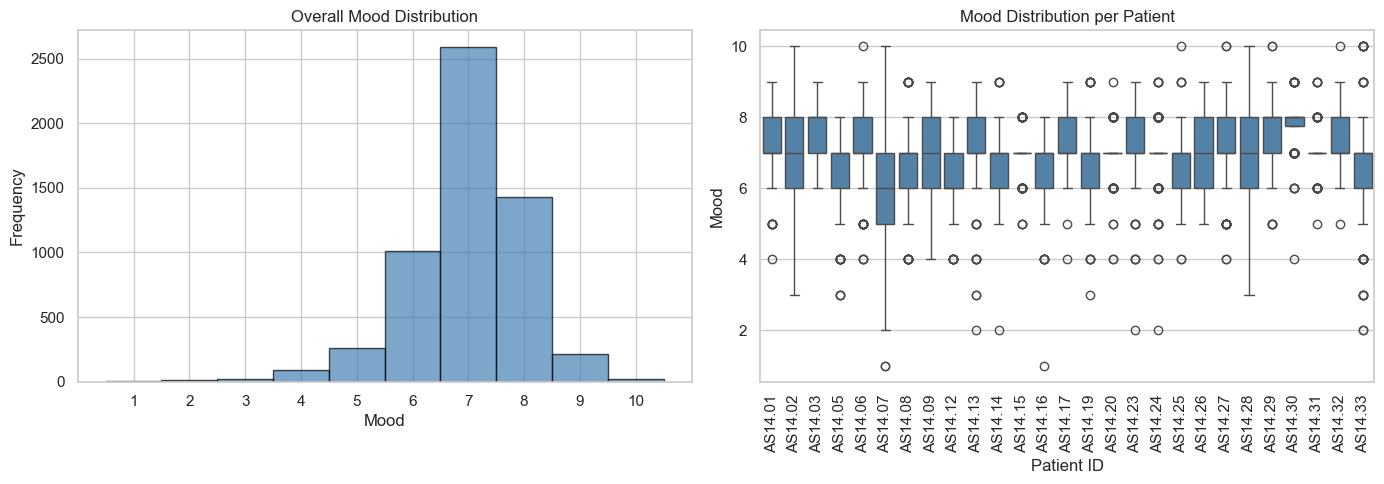

Mood - Mean: 6.99, Median: 7.00, Std: 1.03


In [35]:
# Mood distribution - overall
mood_data = df[df["variable"] == "mood"]["value"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(mood_data, bins=np.arange(0.5, 11.5, 1), color="steelblue", edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Mood")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Overall Mood Distribution")
axes[0].set_xticks(range(1, 11))

sns.boxplot(data=df[df["variable"] == "mood"], x="id", y="value", ax=axes[1], color="steelblue")
axes[1].set_title("Mood Distribution per Patient")
axes[1].set_xlabel("Patient ID")
axes[1].set_ylabel("Mood")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

print(f"Mood - Mean: {mood_data.mean():.2f}, Median: {mood_data.median():.2f}, Std: {mood_data.std():.2f}")

### 5.2 Circumplex Model Variables (Arousal and Valence)

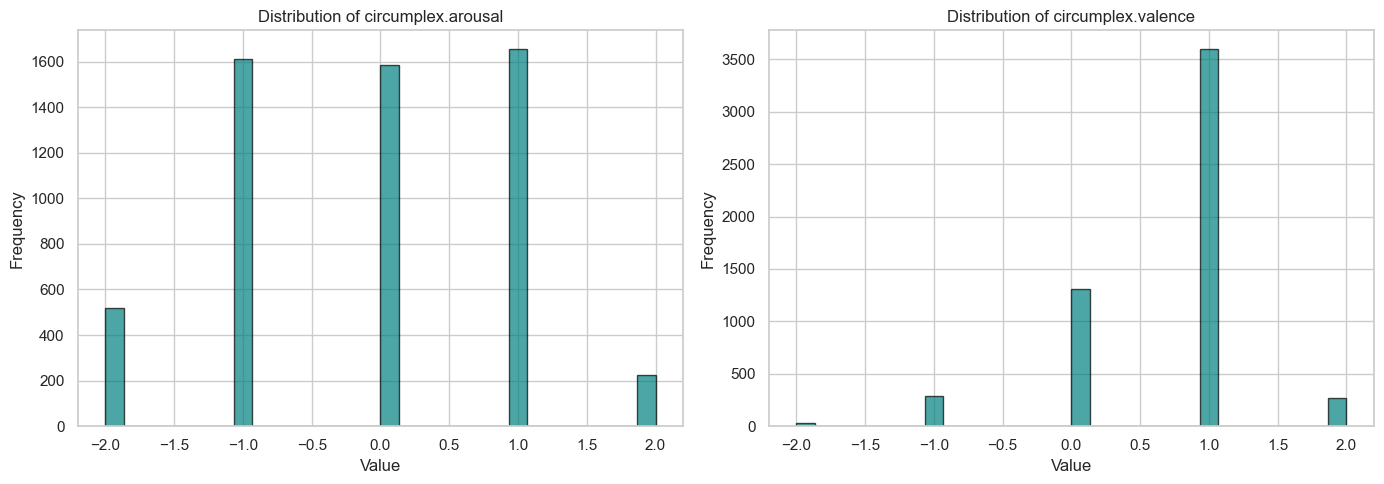

In [36]:
# Circumplex variables
circumplex_vars = ["circumplex.arousal", "circumplex.valence"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, var in enumerate(circumplex_vars):
    data = df[df["variable"] == var]["value"].dropna()
    axes[i].hist(data, bins=30, color="teal", edgecolor="black", alpha=0.7)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")
    axes[i].set_title(f"Distribution of {var}")

plt.tight_layout()
plt.show()

### 5.3 Smartphone Usage Variables (Screen, App Categories)

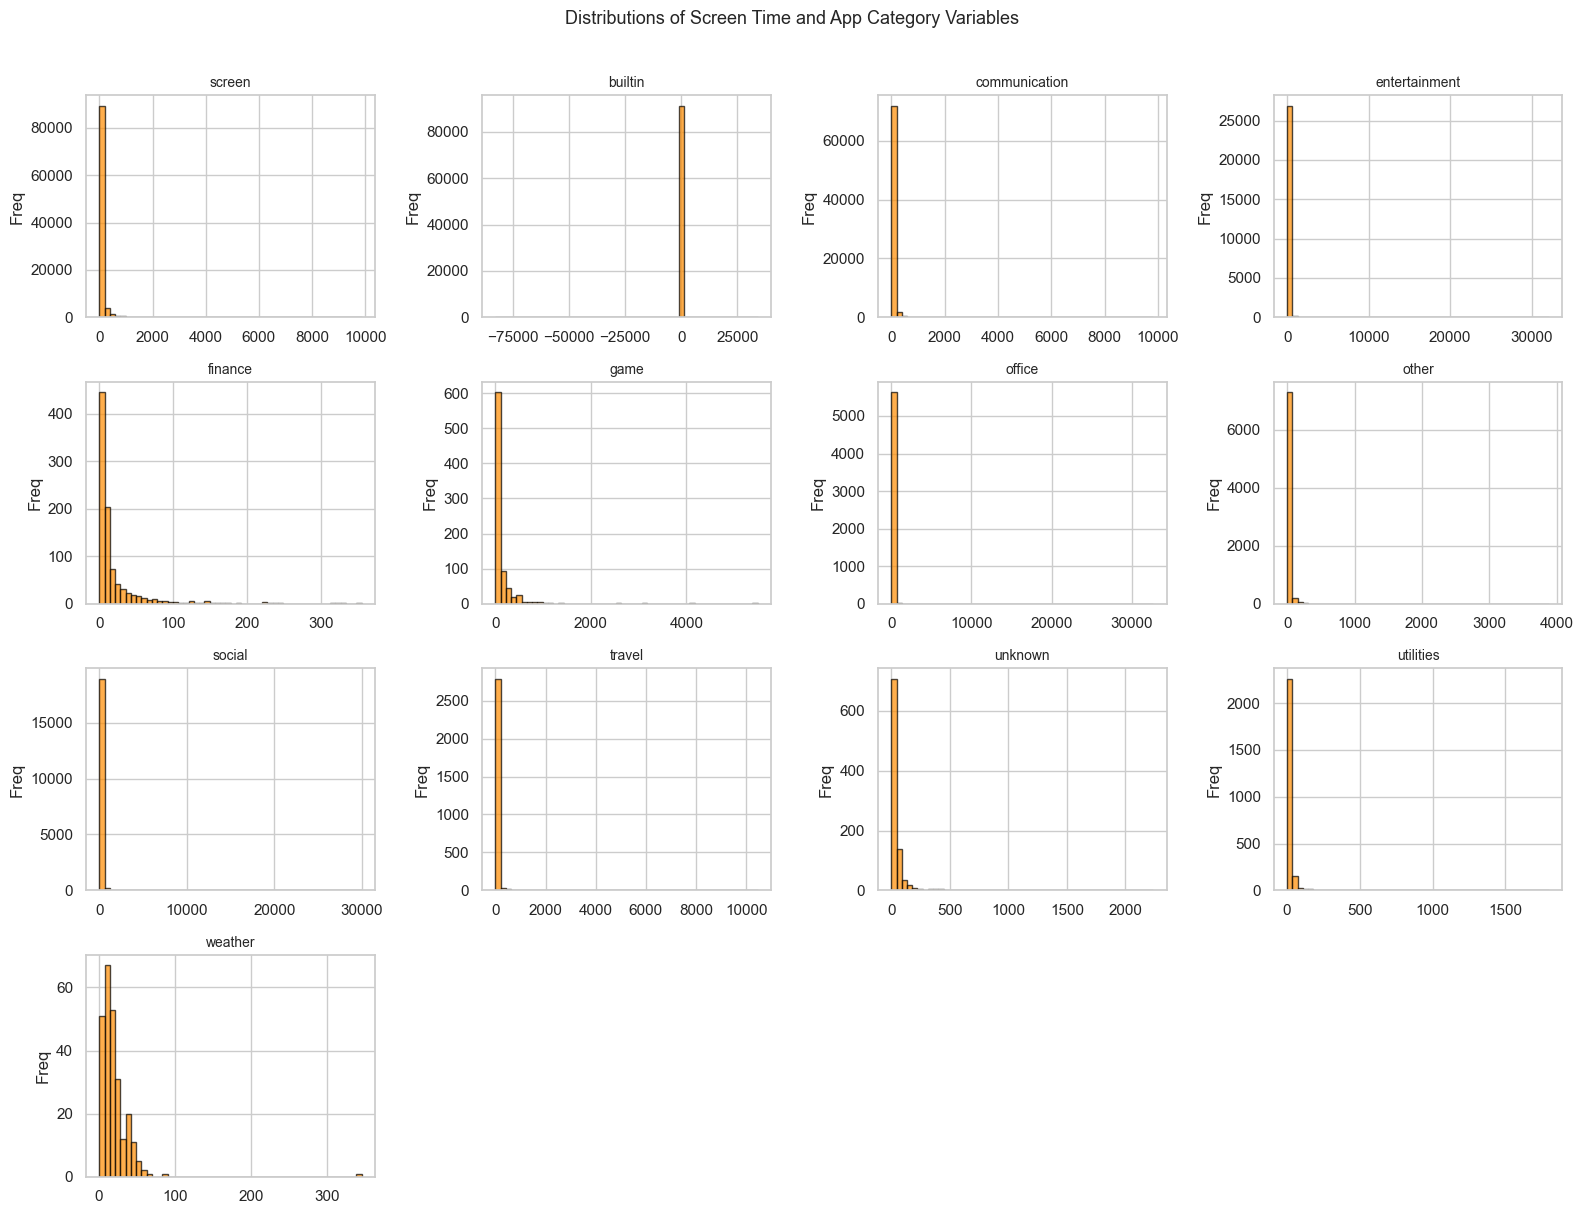

In [37]:
# Distribution of all app category variables and screen time
app_vars = sorted([v for v in df["variable"].unique() if "appCat" in v])
plot_vars = ["screen"] + app_vars

n_cols = 4
n_rows = (len(plot_vars) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for i, var in enumerate(plot_vars):
    data = df[df["variable"] == var]["value"].dropna()
    axes[i].hist(data, bins=50, color="darkorange", edgecolor="black", alpha=0.7)
    axes[i].set_title(var.replace("appCat.", ""), fontsize=10)
    axes[i].set_ylabel("Freq")

# Hide unused subplots
for j in range(len(plot_vars), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distributions of Screen Time and App Category Variables", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 5.4 Activity, Call, and SMS

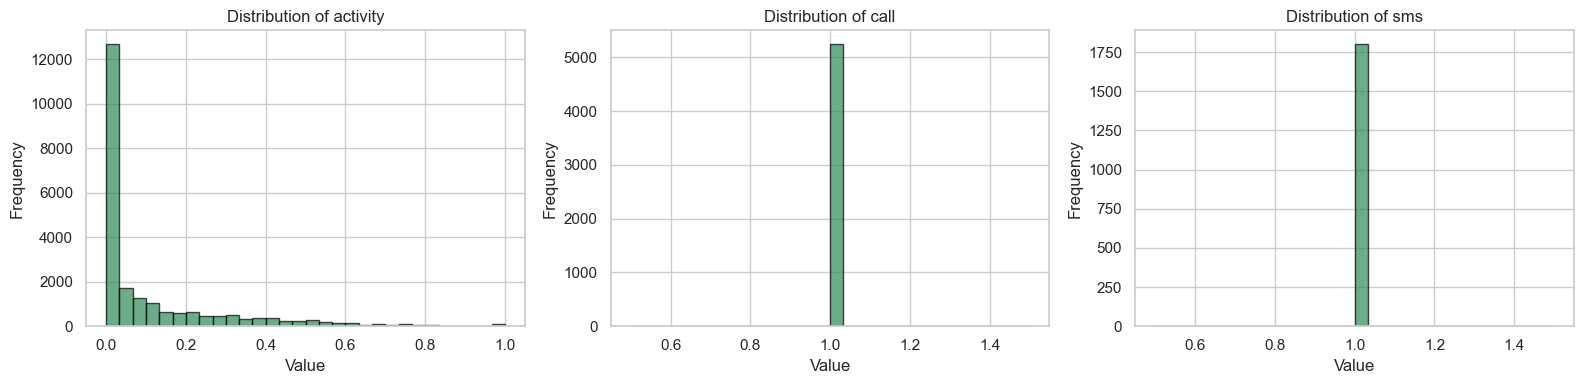

In [38]:
# Activity, call, sms distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, var in enumerate(["activity", "call", "sms"]):
    data = df[df["variable"] == var]["value"].dropna()
    axes[i].hist(data, bins=30, color="seagreen", edgecolor="black", alpha=0.7)
    axes[i].set_title(f"Distribution of {var}")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**TODO: interpret these results.** Comment on the shape of each distribution. Are there skewed variables? What do the binary call/sms distributions tell us? Are there any outliers?

## 6. Time Series Analysis

### 6.1 Mood Over Time per Patient

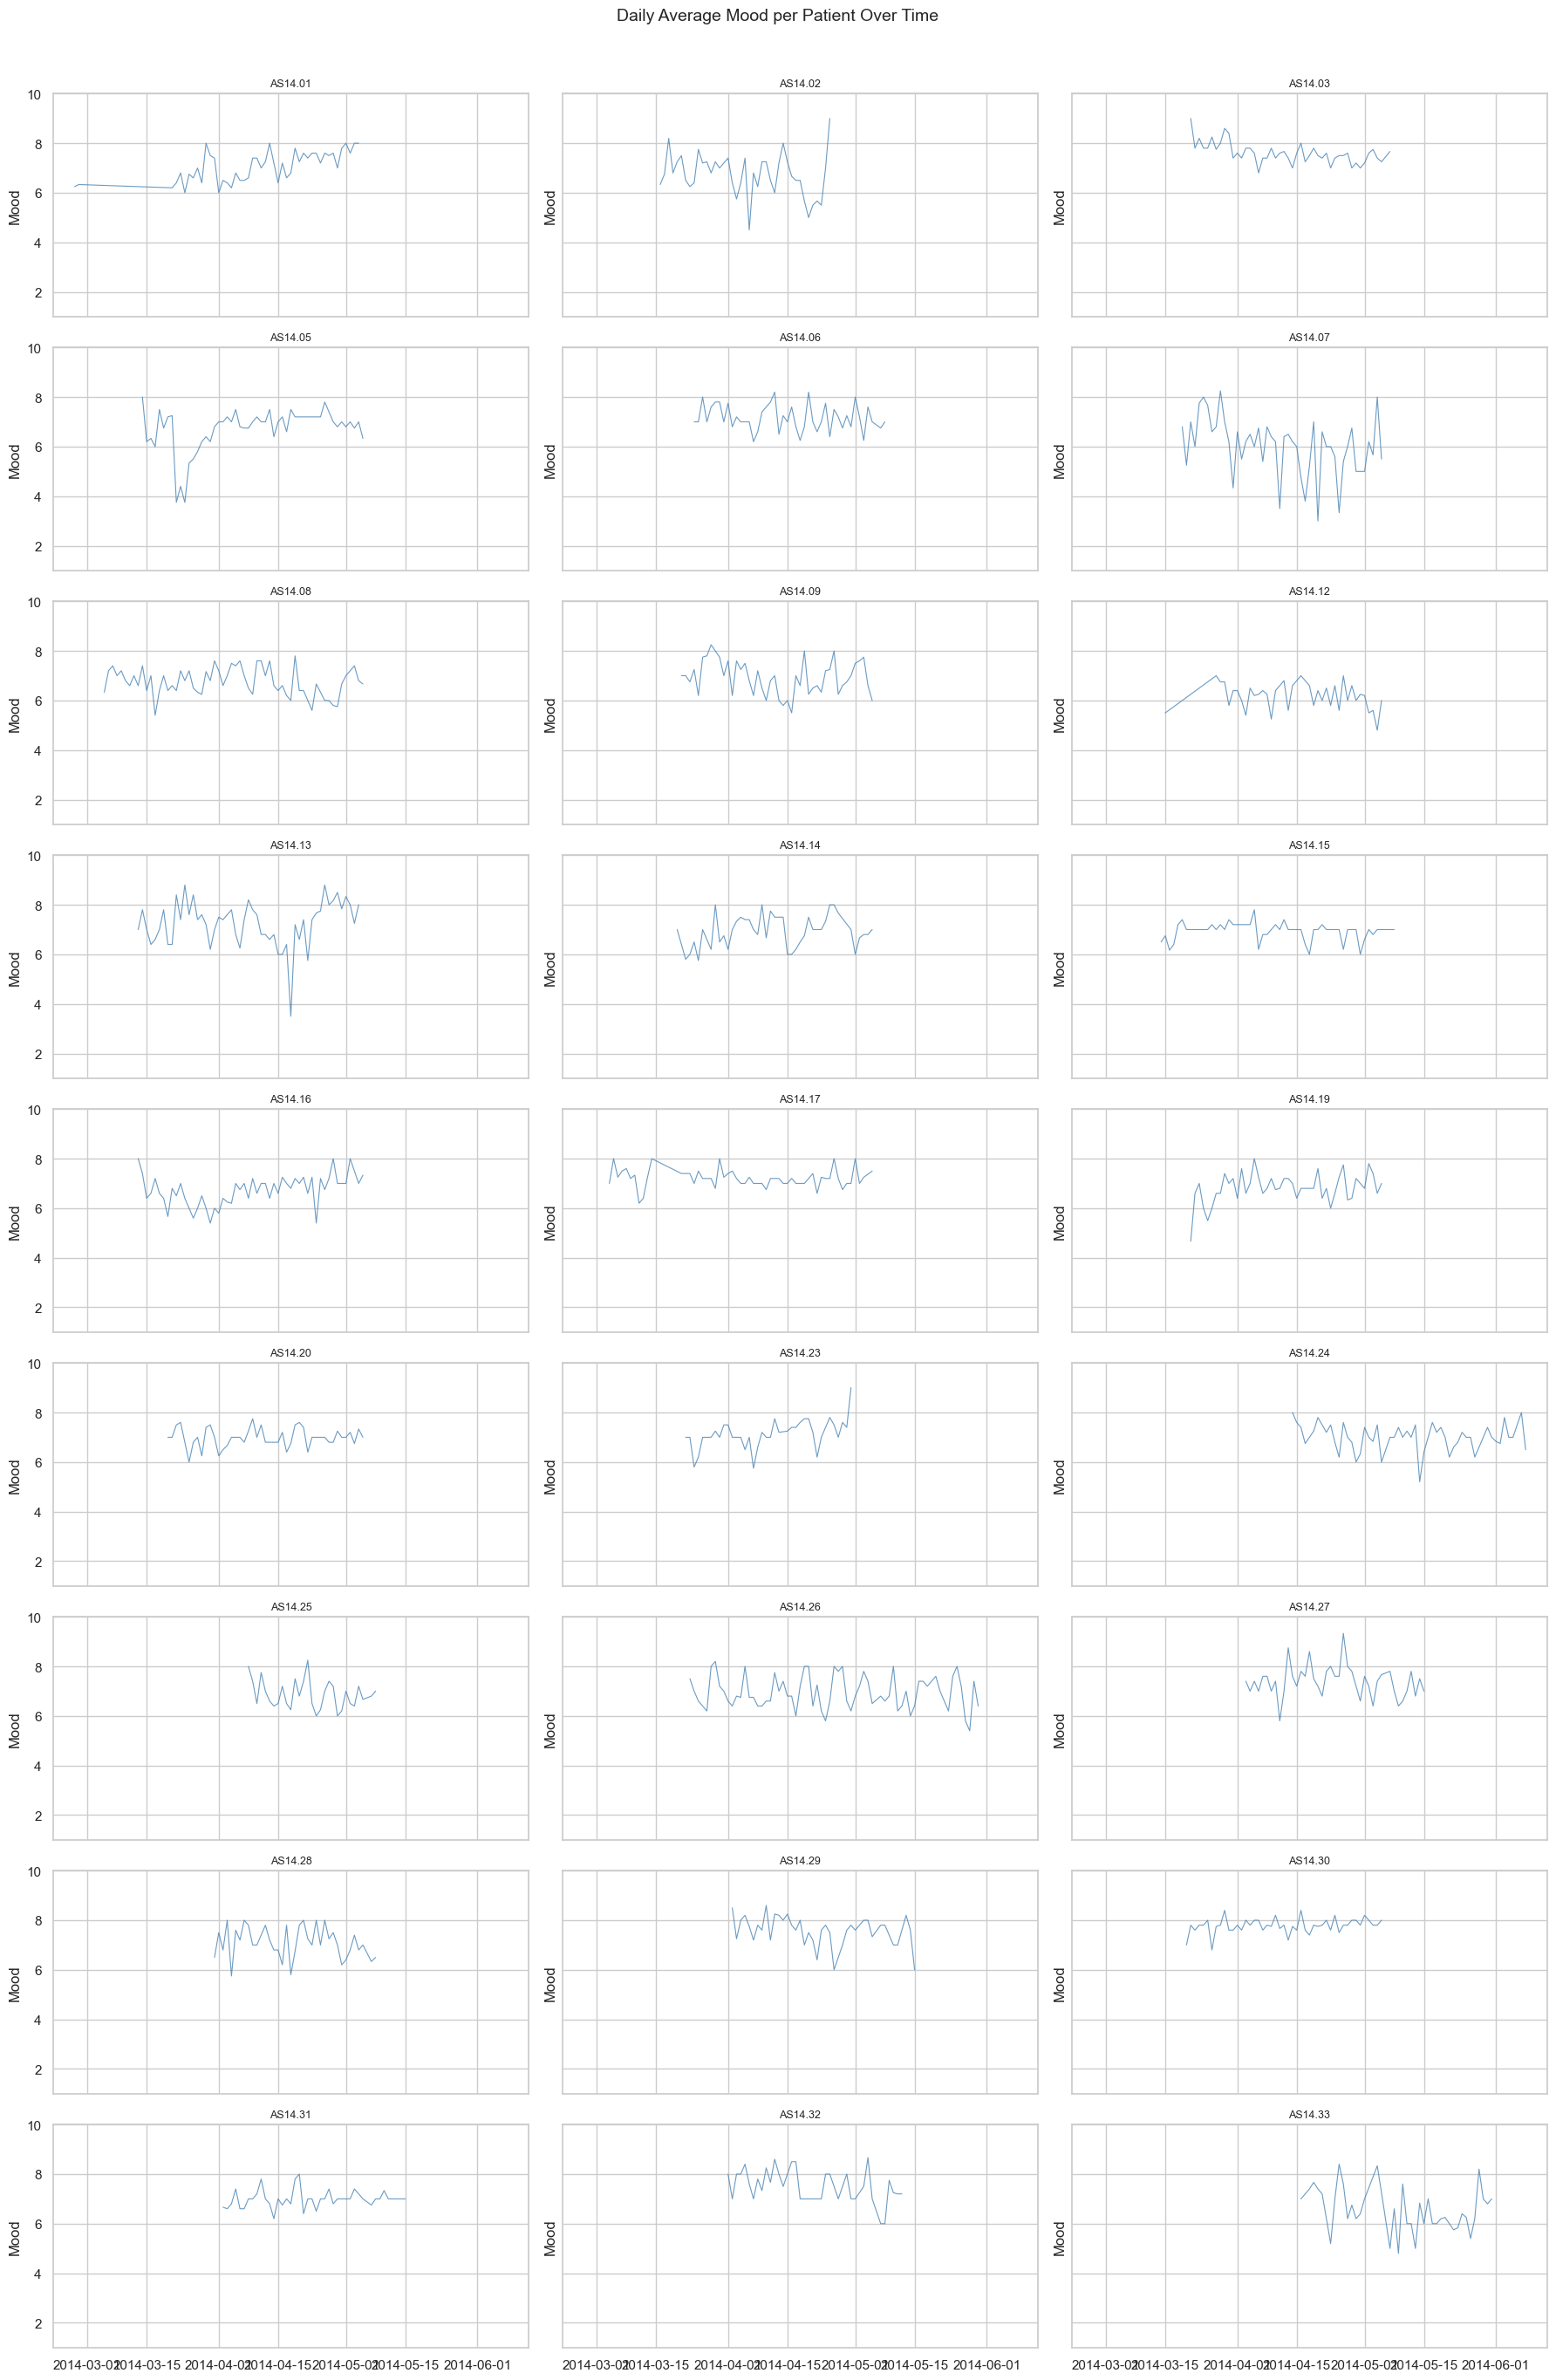

In [39]:
# Daily average mood per patient
mood_df = df[df["variable"] == "mood"].copy()
mood_df["date"] = mood_df["time"].dt.date
daily_mood = mood_df.groupby(["id", "date"])["value"].mean().reset_index()
daily_mood["date"] = pd.to_datetime(daily_mood["date"])

patient_ids = sorted(daily_mood["id"].unique())
n_patients = len(patient_ids)
n_cols = 3
n_rows = (n_patients + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows), sharex=True, sharey=True)
axes = axes.flatten()

for i, pid in enumerate(patient_ids):
    patient_data = daily_mood[daily_mood["id"] == pid]
    axes[i].plot(patient_data["date"], patient_data["value"], linewidth=0.8, alpha=0.8, color="steelblue")
    axes[i].set_title(pid, fontsize=9)
    axes[i].set_ylim(1, 10)
    axes[i].set_ylabel("Mood")

for j in range(len(patient_ids), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Daily Average Mood per Patient Over Time", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 6.2 Overall Mood Trend (Averaged Across Patients)

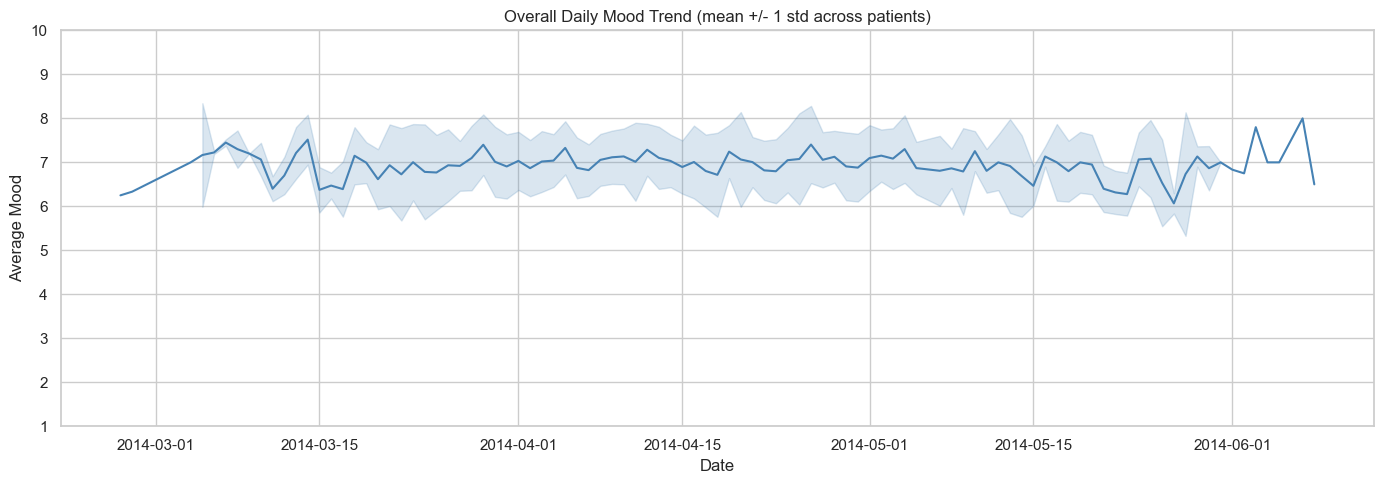

In [40]:
# Overall daily mood trend
overall_daily = daily_mood.groupby("date")["value"].agg(["mean", "std"]).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(overall_daily["date"], overall_daily["mean"], color="steelblue", linewidth=1.5)
ax.fill_between(
    overall_daily["date"],
    overall_daily["mean"] - overall_daily["std"],
    overall_daily["mean"] + overall_daily["std"],
    alpha=0.2, color="steelblue"
)
ax.set_xlabel("Date")
ax.set_ylabel("Average Mood")
ax.set_title("Overall Daily Mood Trend (mean +/- 1 std across patients)")
ax.set_ylim(1, 10)
plt.tight_layout()
plt.show()

### 6.3 Number of Mood Measurements per Day per Patient

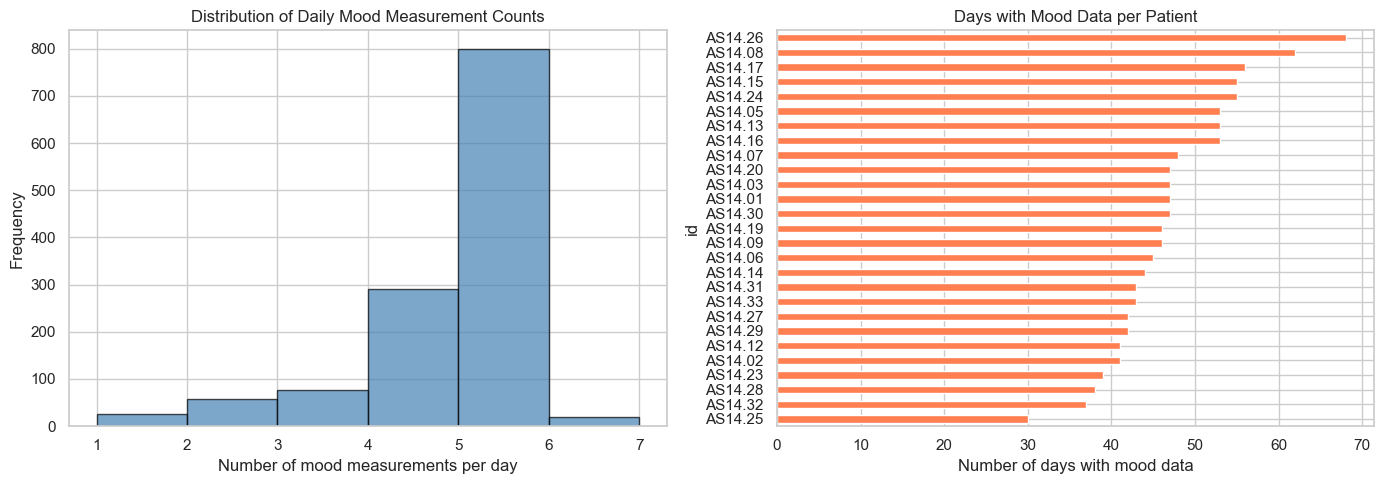

In [41]:
# How many mood measurements per day?
mood_counts_per_day = mood_df.groupby(["id", "date"]).size().reset_index(name="n_measurements")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(mood_counts_per_day["n_measurements"], bins=range(1, mood_counts_per_day["n_measurements"].max() + 2),
             color="steelblue", edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Number of mood measurements per day")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Daily Mood Measurement Counts")

# Days with mood data per patient
days_per_patient = mood_counts_per_day.groupby("id").size().sort_values()
days_per_patient.plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_xlabel("Number of days with mood data")
axes[1].set_title("Days with Mood Data per Patient")

plt.tight_layout()
plt.show()

**TODO: interpret these results.** How many mood measurements do patients typically report per day? Are there patients with very few days of data? What implications does this have for predicting next-day mood?

## 7. Correlation Analysis

We pivot the data to a daily aggregation (mean per day per patient) and compute correlations between variables.

In [42]:
# Create daily aggregated wide-format dataset
df["date"] = df["time"].dt.date
daily_wide = df.pivot_table(index=["id", "date"], columns="variable", values="value", aggfunc="mean")
daily_wide = daily_wide.reset_index()

print(f"Daily wide-format shape: {daily_wide.shape}")
daily_wide.head()

Daily wide-format shape: (1973, 21)


variable,id,date,activity,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,appCat.game,appCat.office,appCat.other,appCat.social,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,call,circumplex.arousal,circumplex.valence,mood,screen,sms
0,AS14.01,2014-02-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,AS14.01,2014-02-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
2,AS14.01,2014-02-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0
3,AS14.01,2014-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0
4,AS14.01,2014-02-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


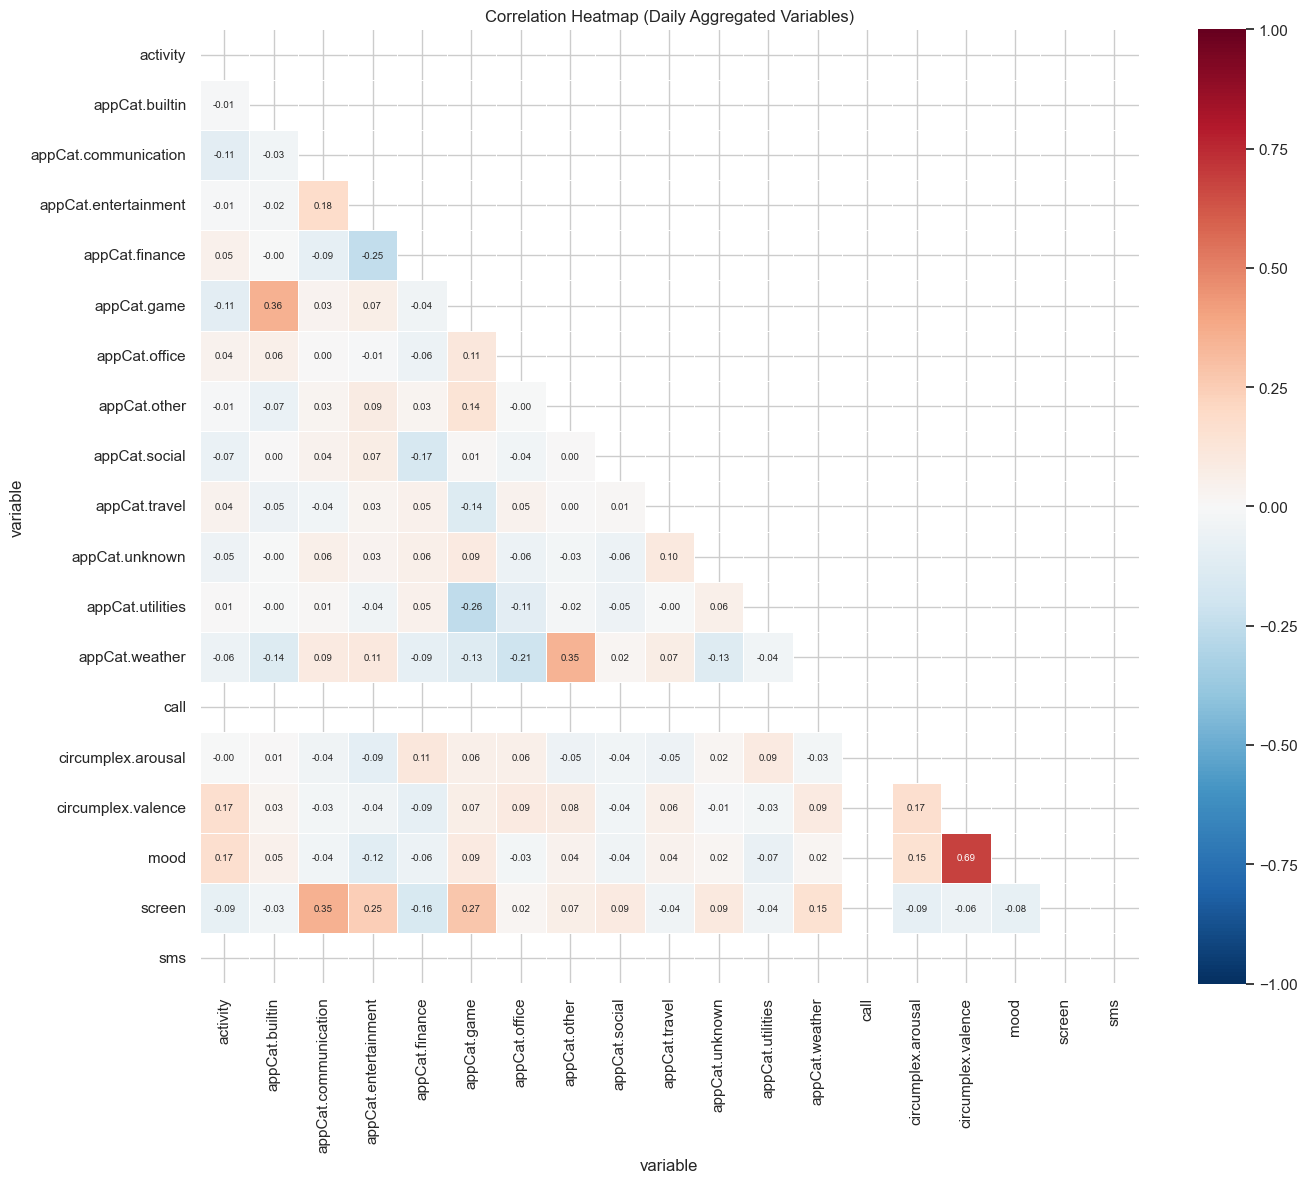

In [43]:
# Correlation heatmap
numeric_cols = [c for c in daily_wide.columns if c not in ["id", "date"]]
corr_matrix = daily_wide[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={"size": 7})
ax.set_title("Correlation Heatmap (Daily Aggregated Variables)")
plt.tight_layout()
plt.show()

In [44]:
# Top correlations with mood
mood_corr = corr_matrix["mood"].drop("mood").sort_values(key=abs, ascending=False)
print("Correlations with mood (sorted by absolute value):")
print(mood_corr.round(3).to_string())

Correlations with mood (sorted by absolute value):
variable
circumplex.valence      0.685
activity                0.167
circumplex.arousal      0.153
appCat.entertainment   -0.117
appCat.game             0.089
screen                 -0.082
appCat.utilities       -0.071
appCat.finance         -0.060
appCat.builtin          0.048
appCat.travel           0.041
appCat.social          -0.041
appCat.other            0.041
appCat.communication   -0.037
appCat.office          -0.026
appCat.unknown          0.022
appCat.weather          0.021
call                      NaN
sms                       NaN


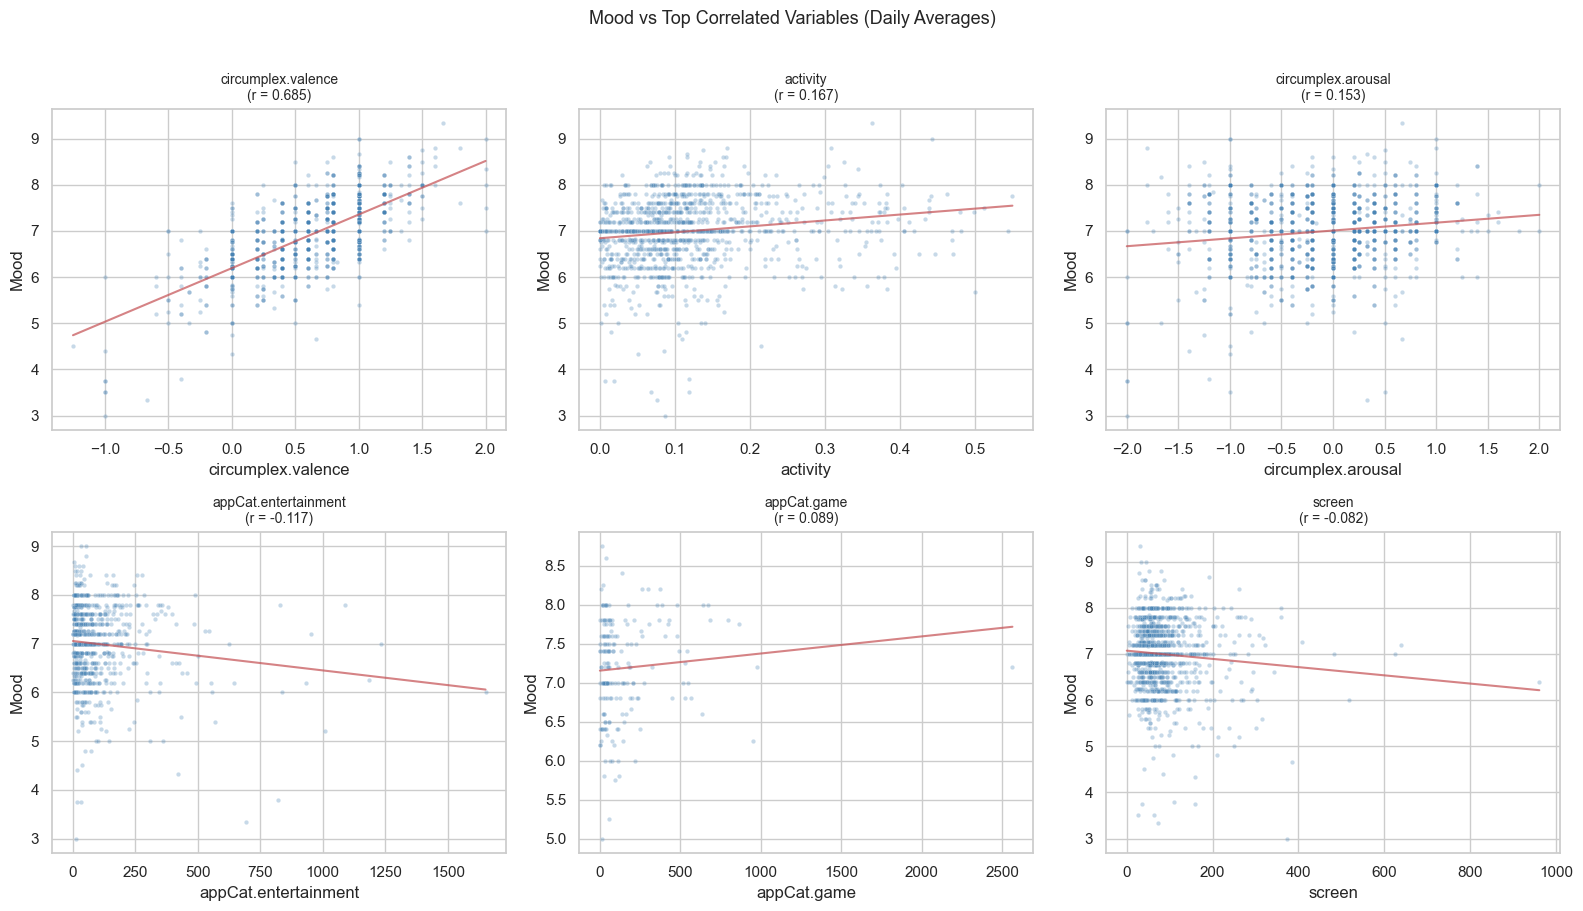

In [45]:
# Scatter plots: mood vs top correlated variables
top_vars = mood_corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, var in enumerate(top_vars):
    sns.scatterplot(data=daily_wide, x=var, y="mood", ax=axes[i], alpha=0.3, s=10, color="steelblue")
    # Add trend line
    valid = daily_wide[[var, "mood"]].dropna()
    if len(valid) > 2:
        z = np.polyfit(valid[var], valid["mood"], 1)
        p = np.poly1d(z)
        x_range = np.linspace(valid[var].min(), valid[var].max(), 100)
        axes[i].plot(x_range, p(x_range), "r-", linewidth=1.5, alpha=0.7)
    corr_val = mood_corr[var]
    axes[i].set_title(f"{var}\n(r = {corr_val:.3f})", fontsize=10)
    axes[i].set_ylabel("Mood")

fig.suptitle("Mood vs Top Correlated Variables (Daily Averages)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**TODO: interpret these results.** Which variables are most strongly correlated with mood? Are the correlations expected (e.g., valence and mood)? Are there surprising relationships? What does this suggest for feature selection in the prediction task?

## 8. Target Variable: Next-Day Mood

Since the goal is to predict next-day mood (daily average), let us examine the target distribution.

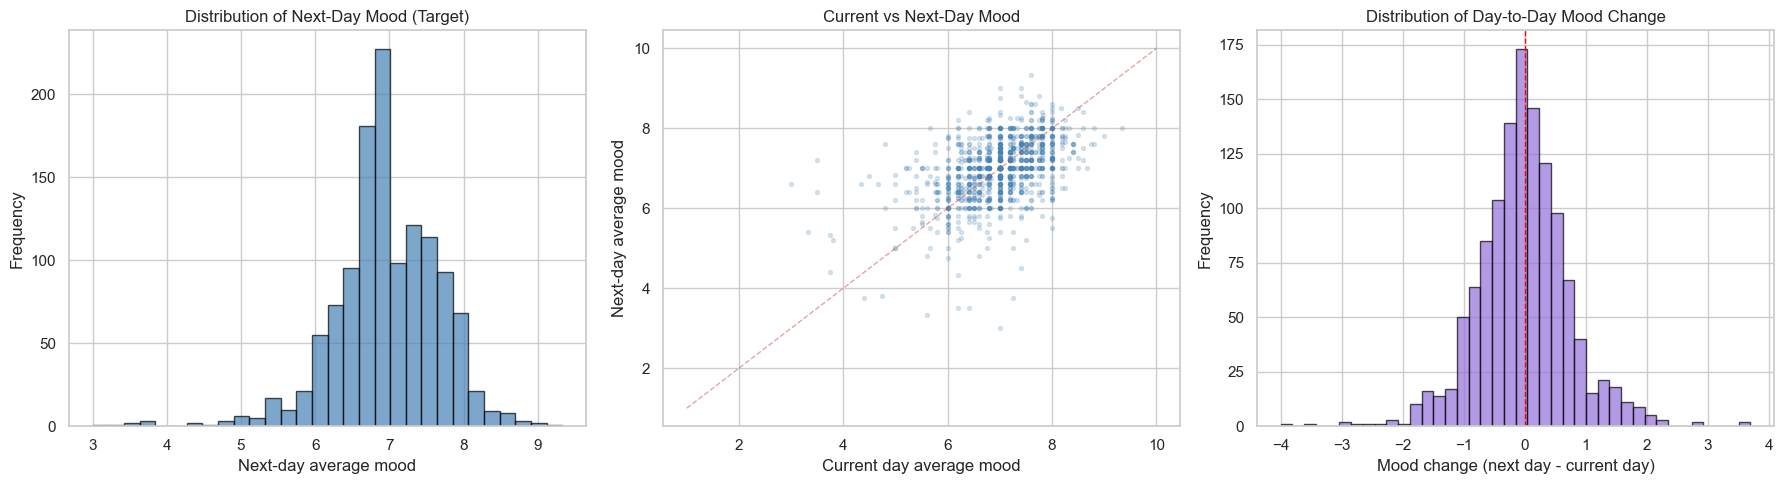

Correlation between current-day and next-day mood: 0.469
Mean mood change: -0.000
Std of mood change: 0.756


In [46]:
# Next-day mood target
daily_mood_target = daily_mood.copy()
daily_mood_target = daily_mood_target.sort_values(["id", "date"])
daily_mood_target["next_day_mood"] = daily_mood_target.groupby("id")["value"].shift(-1)
daily_mood_target = daily_mood_target.dropna(subset=["next_day_mood"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution of next-day mood
axes[0].hist(daily_mood_target["next_day_mood"], bins=30, color="steelblue", edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Next-day average mood")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Next-Day Mood (Target)")

# Current mood vs next-day mood
axes[1].scatter(daily_mood_target["value"], daily_mood_target["next_day_mood"], alpha=0.2, s=8, color="steelblue")
axes[1].plot([1, 10], [1, 10], "r--", linewidth=1, alpha=0.5)
axes[1].set_xlabel("Current day average mood")
axes[1].set_ylabel("Next-day average mood")
axes[1].set_title("Current vs Next-Day Mood")

# Autocorrelation: mood change distribution
daily_mood_target["mood_change"] = daily_mood_target["next_day_mood"] - daily_mood_target["value"]
axes[2].hist(daily_mood_target["mood_change"], bins=40, color="mediumpurple", edgecolor="black", alpha=0.7)
axes[2].axvline(x=0, color="red", linestyle="--", linewidth=1)
axes[2].set_xlabel("Mood change (next day - current day)")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Distribution of Day-to-Day Mood Change")

plt.tight_layout()
plt.show()

corr_val = daily_mood_target["value"].corr(daily_mood_target["next_day_mood"])
print(f"Correlation between current-day and next-day mood: {corr_val:.3f}")
print(f"Mean mood change: {daily_mood_target['mood_change'].mean():.3f}")
print(f"Std of mood change: {daily_mood_target['mood_change'].std():.3f}")

**TODO: interpret these results.** How autocorrelated is mood from one day to the next? What does this imply for prediction difficulty? Is the target variable approximately normally distributed?

## 9. Temporal Patterns

### 9.1 Mood by Day of Week and Hour of Day

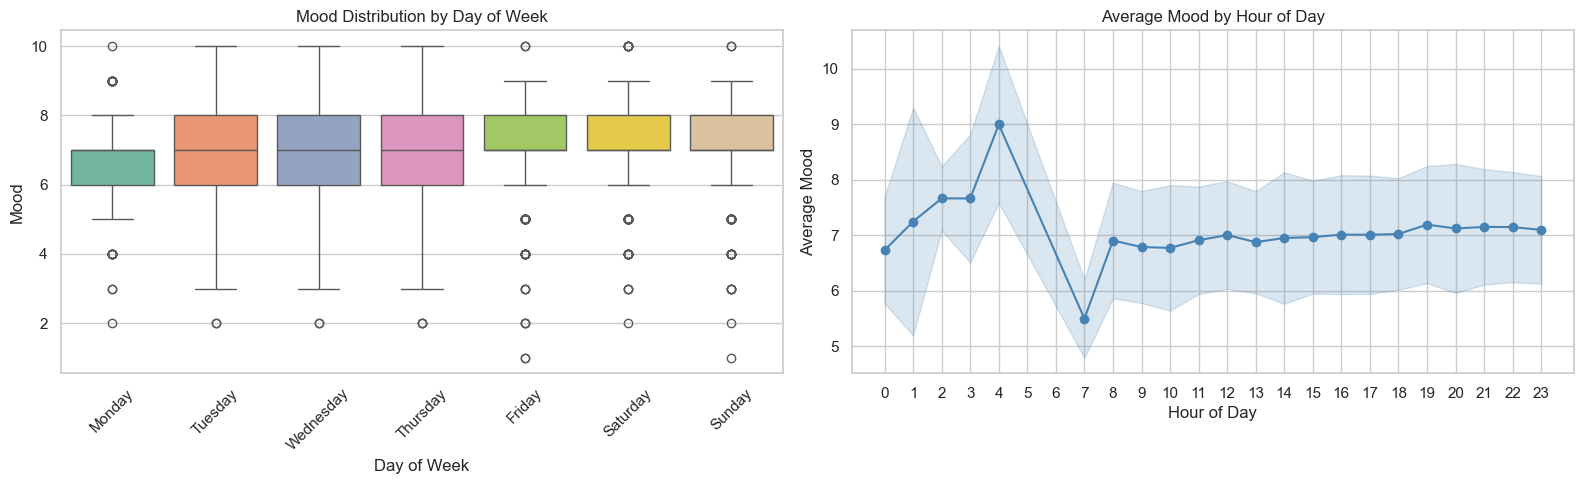

In [47]:
# Mood by day of week and hour
mood_temporal = df[df["variable"] == "mood"].copy()
mood_temporal["day_of_week"] = mood_temporal["time"].dt.day_name()
mood_temporal["hour"] = mood_temporal["time"].dt.hour

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# By day of week
sns.boxplot(data=mood_temporal, x="day_of_week", y="value", order=day_order, ax=axes[0],
            palette="Set2")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Mood")
axes[0].set_title("Mood Distribution by Day of Week")
axes[0].tick_params(axis="x", rotation=45)

# By hour of day
hourly_mood = mood_temporal.groupby("hour")["value"].agg(["mean", "std"]).reset_index()
axes[1].plot(hourly_mood["hour"], hourly_mood["mean"], "o-", color="steelblue")
axes[1].fill_between(hourly_mood["hour"],
                     hourly_mood["mean"] - hourly_mood["std"],
                     hourly_mood["mean"] + hourly_mood["std"],
                     alpha=0.2, color="steelblue")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Average Mood")
axes[1].set_title("Average Mood by Hour of Day")
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

**TODO: interpret these results.** Is there a day-of-week effect on mood? Does mood vary throughout the day? Could these temporal patterns be useful features for prediction?

## 10. Inter-Patient Variability

Comparing how variable distributions differ across patients.

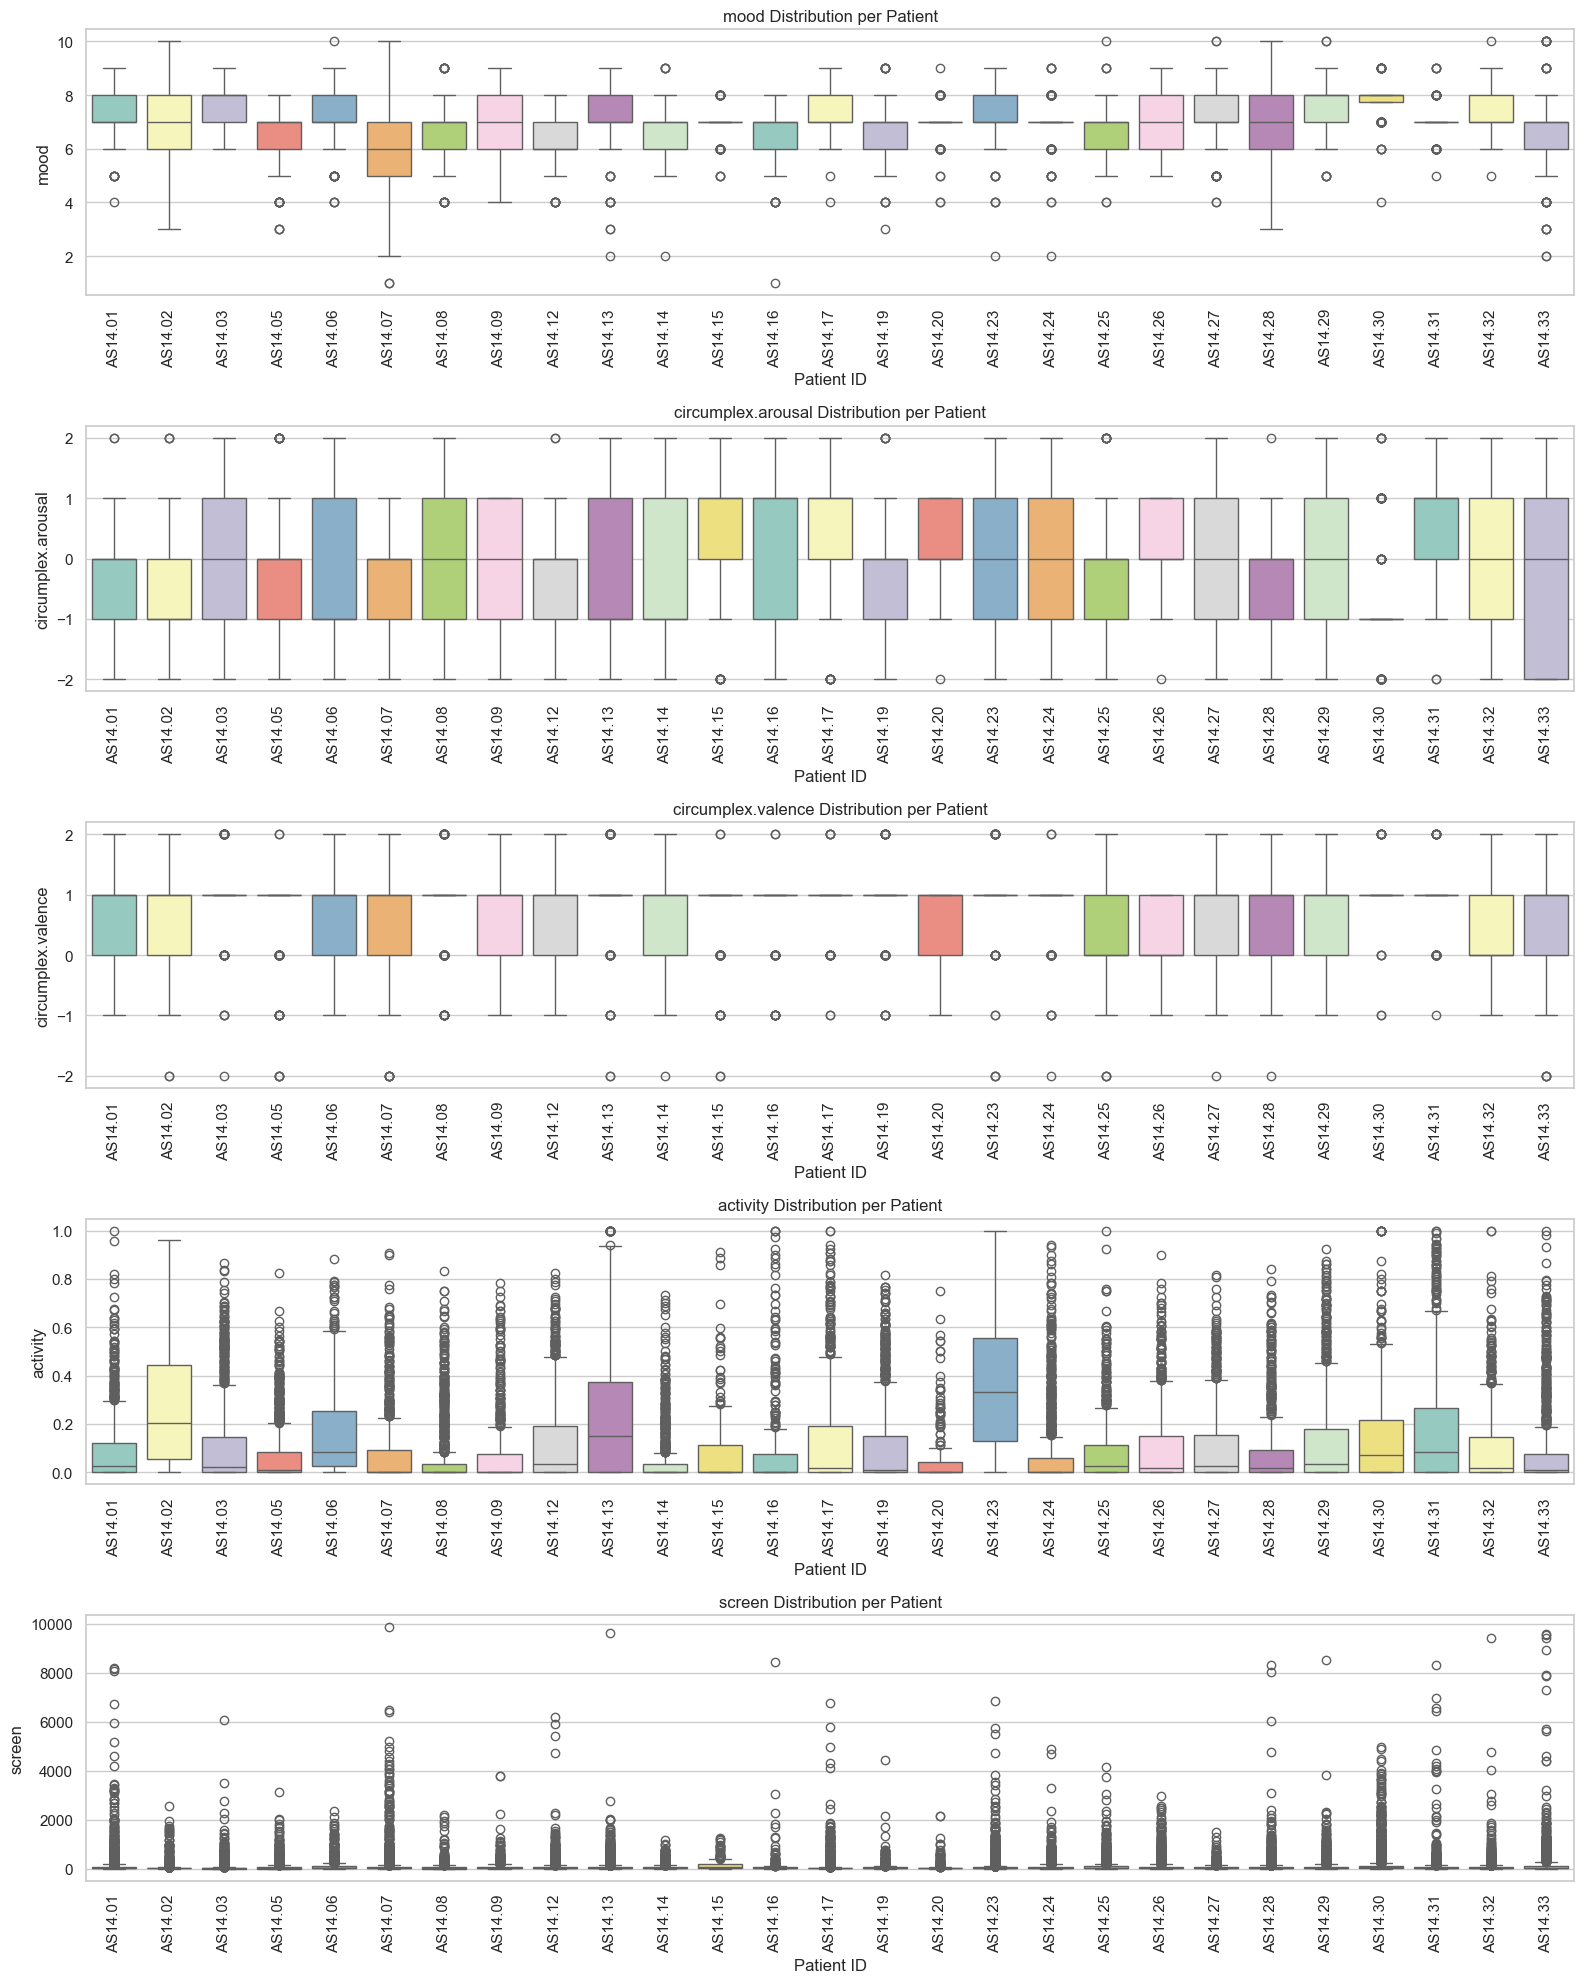

In [48]:
# Key variables: boxplots per patient
key_vars = ["mood", "circumplex.arousal", "circumplex.valence", "activity", "screen"]

fig, axes = plt.subplots(len(key_vars), 1, figsize=(16, 4 * len(key_vars)))

for i, var in enumerate(key_vars):
    var_data = df[df["variable"] == var]
    sns.boxplot(data=var_data, x="id", y="value", ax=axes[i], palette="Set3",
                order=sorted(var_data["id"].unique()))
    axes[i].set_title(f"{var} Distribution per Patient")
    axes[i].set_xlabel("Patient ID")
    axes[i].set_ylabel(var)
    axes[i].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

**TODO: interpret these results.** Is there high variability between patients? Would a single model work for all patients, or should per-patient models be considered? Are there patients with notably different patterns?

## 11. Summary of Key Findings

**TODO: Write a summary of the key findings from this EDA.** Cover the following points:

- How many records, patients, and variables are in the dataset? What time period does it span?
- What are the main types of variables (self-reported mood, sensor data, phone usage)?
- Which variables have the most missing data, and what patterns do we see?
- What does the mood distribution look like overall and per patient?
- Which variables show the strongest relationship with mood?
- Are there temporal patterns (day of week, time of day) in mood?
- How much do patients differ from each other?
- What are the implications for the prediction task (next-day mood)?